Описание задания
Классификация тарелок на грязные и чистые на основе датасета конкурса PlatesV2.

Перейдите на платформу kaggle на описание проекта, который вы будете выполнять:
Проект 1: Классификация тарелок (грязные/чистые) с использованием датасета PlatesV2

Выполните задание, описанное на платформе.
Подготовьте проект: описание результатов работы в Google Doc / Яндекс документах и код с комментариями.

In [113]:
import os
import zipfile
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from PIL import Image
import clip
import numpy as np

In [114]:
#Определяем устройство для выполнения вычислений (GPU или CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_clean = "./plates/train/cleaned"
train_dirty = "./plates/train/dirty"
test_path = "./plates/test"

def is_image_file(filename):
    return filename.lower().endswith(('.png', '.jpg', '.jpeg'))

#Получаем список путей к изображениям чистых и грязных тарелок
clean_images = [os.path.join(train_clean, f) for f in os.listdir(train_clean) if is_image_file(f)]
dirty_images = [os.path.join(train_dirty, f) for f in os.listdir(train_dirty) if is_image_file(f)]

In [115]:
X_train = clean_images + dirty_images
y_train = [1] * len(clean_images) + [0] * len(dirty_images)
X_test = [os.path.join(test_path, f) for f in sorted(os.listdir(test_path)) if is_image_file(f)]

n_clean = sum(y_train)
n_dirty = len(y_train) - n_clean

print(f"Количество чистых тарелок в тренировчной выборке: {n_clean}, Количество грязных тарелок в тренировчной выборке: {n_dirty}")
print(f"Количество изображений в тренировчной выборке: {len(X_train)}, Количество изображений в тестовой выборке: {len(X_test)}")

Количество чистых тарелок в тренировчной выборке: 20, Количество грязных тарелок в тренировчной выборке: 20
Количество изображений в тренировчной выборке: 40, Количество изображений в тестовой выборке: 744


Разделяем данные на обучающую и валидационную выборки с сохранением пропорций классов

In [116]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
)

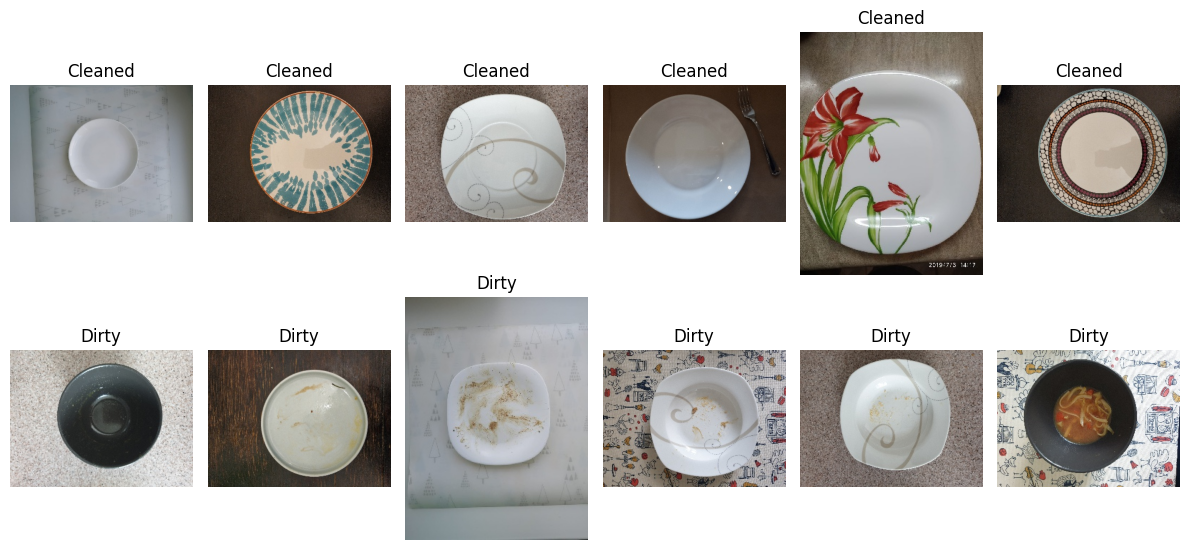

In [117]:
#Функция для отображения примеров изображений
def show_examples(paths, labels, n_clean=6, n_dirty=6):
    clean_idxs = [i for i, l in enumerate(labels) if l == 1][:n_clean]
    dirty_idxs = [i for i, l in enumerate(labels) if l == 0][:n_dirty]
    selected_idxs = clean_idxs + dirty_idxs
    plt.figure(figsize=(12, 6))
    for i, idx in enumerate(selected_idxs):
        img = Image.open(paths[idx])
        label = labels[idx]
        plt.subplot(2, 6, i + 1)
        plt.imshow(img)
        plt.title("Cleaned" if label == 1 else "Dirty")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_examples(X_train, y_train)

In [118]:
class PlateDataset(Dataset):
    def __init__(self, image_paths, labels=None, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        if self.labels is not None:
            return image, self.labels[idx]
        else:
            return image, os.path.basename(img_path)

In [119]:
#Аугментации и преобразования
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [120]:
train_dataset = PlateDataset(X_train, y_train, transform=train_transform)
val_dataset = PlateDataset(X_val, y_val, transform=test_transform)
test_dataset = PlateDataset(X_test, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [121]:
#Загружаем предобученную модель CLIP и модифицируем ее для классификации
model, preprocess = clip.load("ViT-B/32", device=device)
model = model.float()

In [122]:
class CLIPClassifier(nn.Module):
    def __init__(self):
        super(CLIPClassifier, self).__init__()
        self.clip_model = model.visual
        self.fc = nn.Linear(512, 2)

    def forward(self, x):
        with torch.no_grad():
            x = self.clip_model(x)
        return self.fc(x)

#Создаем экземпляр классификатора и перемещаем его на устройство
classifier = CLIPClassifier().to(device)

In [123]:
#Определяем функцию потерь и оптимизатор
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(classifier.fc.parameters(), lr=0.005)

In [124]:
num_epochs = 30
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    classifier.train()
    running_loss = 0.0
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = classifier(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        train_losses.append(running_loss / len(train_loader))
        train_accuracies.append(correct / total)
        
    # Оцениваем модель на валидационной выборке
    val_loss, val_acc, _, _ = evaluate_model(classifier, val_loader, criterion)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs}, Accuracy: {(1- (running_loss/len(train_loader))) * 100}%")

Epoch 1/30, Accuracy: 27.84150242805481%
Epoch 2/30, Accuracy: 36.73943281173706%
Epoch 3/30, Accuracy: 43.78132224082947%
Epoch 4/30, Accuracy: 49.69601631164551%
Epoch 5/30, Accuracy: 56.61381781101227%
Epoch 6/30, Accuracy: 55.17796277999878%
Epoch 7/30, Accuracy: 65.81110954284668%
Epoch 8/30, Accuracy: 66.70820116996765%
Epoch 9/30, Accuracy: 68.81955564022064%
Epoch 10/30, Accuracy: 74.70178306102753%
Epoch 11/30, Accuracy: 72.62485027313232%
Epoch 12/30, Accuracy: 75.25408864021301%
Epoch 13/30, Accuracy: 77.46489644050598%
Epoch 14/30, Accuracy: 75.30766129493713%
Epoch 15/30, Accuracy: 77.49117910861969%
Epoch 16/30, Accuracy: 80.93531876802444%
Epoch 17/30, Accuracy: 82.46322274208069%
Epoch 18/30, Accuracy: 81.55912905931473%
Epoch 19/30, Accuracy: 80.05945831537247%
Epoch 20/30, Accuracy: 83.71257483959198%
Epoch 21/30, Accuracy: 84.92975234985352%
Epoch 22/30, Accuracy: 87.12662607431412%
Epoch 23/30, Accuracy: 86.90529465675354%
Epoch 24/30, Accuracy: 87.0810717344284%
Ep

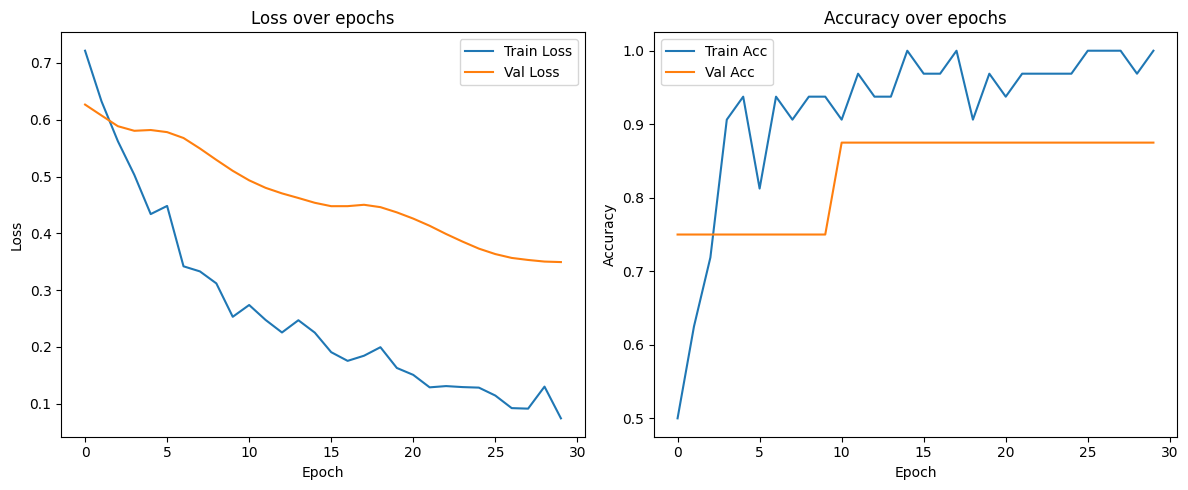

In [125]:
#Построение графиков потерь и точности
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Acc')
plt.plot(val_accuracies, label='Val Acc')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [126]:
#Функция для оценки модели на валидационной выборке
def evaluate_model(model, data_loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    acc = accuracy_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)
    cr = classification_report(all_labels, all_preds, target_names=["Dirty", "Clean"])

    return avg_loss, acc, cm, cr

In [127]:
#Оцениваем модель на валидационной выборке
val_loss, val_acc, val_cm, val_cr = evaluate_model(classifier, val_loader, criterion)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print("Confusion Matrix:")
print(val_cm)
print("Classification Report:")
print(val_cr)

Validation Loss: 0.3493
Validation Accuracy: 0.8750
Confusion Matrix:
[[3 1]
 [0 4]]
Classification Report:
              precision    recall  f1-score   support

       Dirty       1.00      0.75      0.86         4
       Clean       0.80      1.00      0.89         4

    accuracy                           0.88         8
   macro avg       0.90      0.88      0.87         8
weighted avg       0.90      0.88      0.87         8



Normalized confusion matrix
[[0.75 0.25]
 [0.   1.  ]]


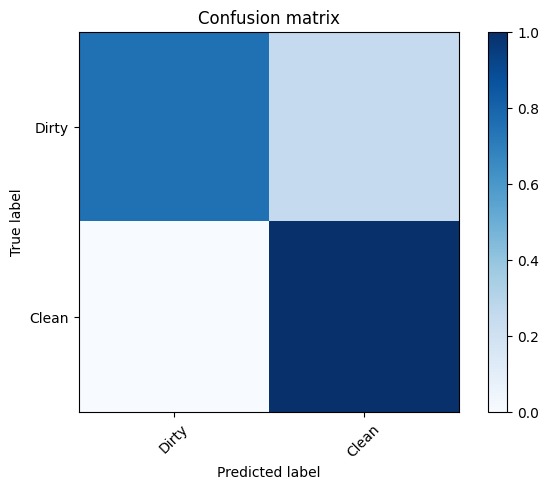

In [128]:
#Функция для построения матрицы ошибок
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

plot_confusion_matrix(val_cm, classes=["Dirty", "Clean"], normalize=True)